### Machine Learning 
#### Practice 3

A bank wants to reduce losses. For each applicant, we must predict:
- Bad risk (1) vs Good risk (0)
and produce a simple business decision recommendation.

Statlog (German Credit Data)
Donated on 11/16/1994
This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix

Cost Matrix

This dataset requires use of a cost matrix,

It is worse to class a customer as good when they are bad (5), 
than it is to class a customer as bad when they are good (1).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as ss

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import column_or_1d

1) Data Loading and Business Understanding
Task 1.1 Load dataset
- Load German Credit dataset into pandas DataFrame.
https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data
- Show:
  - number of rows/columns
  - first 5 rows
  - target distribution (how many good vs bad)

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
df = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 
  
# metadata 
print(statlog_german_credit_data.metadata) 
  
# variable information 
print(statlog_german_credit_data.variables) 


{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

In [3]:
display(df.head())

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201



Attribute 1:  (qualitative)
	       Status of existing checking account
               A11 :      ... <    0 DM
	       A12 : 0 <= ... <  200 DM
	       A13 :      ... >= 200 DM /
		     salary assignments for at least 1 year
               A14 : no checking account

Attribute 2:  (numerical)
	      Duration in month

Attribute 3:  (qualitative)
	      Credit history
	      A30 : no credits taken/
		    all credits paid back duly
              A31 : all credits at this bank paid back duly
	      A32 : existing credits paid back duly till now
              A33 : delay in paying off in the past
	      A34 : critical account/
		    other credits existing (not at this bank)

Attribute 4:  (qualitative)
	      Purpose
	      A40 : car (new)
	      A41 : car (used)
	      A42 : furniture/equipment
	      A43 : radio/television
	      A44 : domestic appliances
	      A45 : repairs
	      A46 : education
	      A47 : (vacation - does not exist?)
	      A48 : retraining
	      A49 : business
	      A410 : others

Attribute 5:  (numerical)
	      Credit amount

Attibute 6:  (qualitative)
	      Savings account/bonds
	      A61 :          ... <  100 DM
	      A62 :   100 <= ... <  500 DM
	      A63 :   500 <= ... < 1000 DM
	      A64 :          .. >= 1000 DM
              A65 :   unknown/ no savings account

Attribute 7:  (qualitative)
	      Present employment since
	      A71 : unemployed
	      A72 :       ... < 1 year
	      A73 : 1  <= ... < 4 years  
	      A74 : 4  <= ... < 7 years
	      A75 :       .. >= 7 years

Attribute 8:  (numerical)
	      Installment rate in percentage of disposable income

Attribute 9:  (qualitative)
	      Personal status and sex
	      A91 : male   : divorced/separated
	      A92 : female : divorced/separated/married
              A93 : male   : single
	      A94 : male   : married/widowed
	      A95 : female : single

Attribute 10: (qualitative)
	      Other debtors / guarantors
	      A101 : none
	      A102 : co-applicant
	      A103 : guarantor

Attribute 11: (numerical)
	      Present residence since

Attribute 12: (qualitative)
	      Property
	      A121 : real estate
	      A122 : if not A121 : building society savings agreement/
				   life insurance
              A123 : if not A121/A122 : car or other, not in attribute 6
	      A124 : unknown / no property

Attribute 13: (numerical)
	      Age in years

Attribute 14: (qualitative)
	      Other installment plans 
	      A141 : bank
	      A142 : stores
	      A143 : none

Attribute 15: (qualitative)
	      Housing
	      A151 : rent
	      A152 : own
	      A153 : for free

Attribute 16: (numerical)
              Number of existing credits at this bank

Attribute 17: (qualitative)
	      Job
	      A171 : unemployed/ unskilled  - non-resident
	      A172 : unskilled - resident
	      A173 : skilled employee / official
	      A174 : management/ self-employed/
		     highly qualified employee/ officer

Attribute 18: (numerical)
	      Number of people being liable to provide maintenance for

Attribute 19: (qualitative)
	      Telephone
	      A191 : none
	      A192 : yes, registered under the customers name

Attribute 20: (qualitative)
	      foreign worker
	      A201 : yes
	      A202 : no


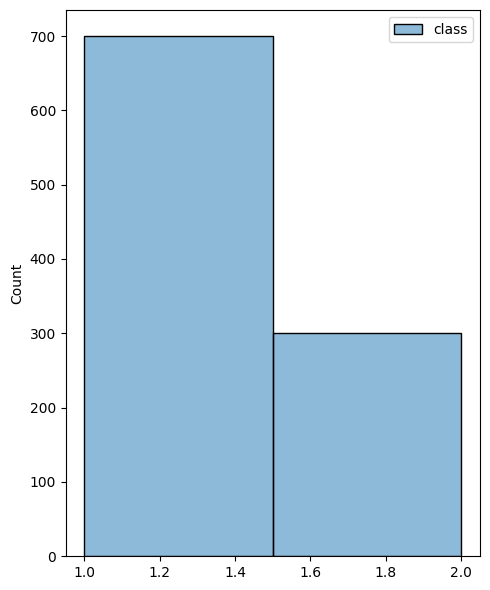

Amount of "Bad" is 30.0 %


In [4]:
# target distribution

plt.figure(figsize=(5, 6))
sns.histplot(data=y, bins=2)

plt.tight_layout()
plt.show()

bad_percentage = len(y[y.eq(2).any(axis=1)])/len(y) * 100
print('Amount of "Bad" is', bad_percentage, '%')

1 - good, 700
2 - bad, 300

##### What is a “default / bad risk” in a bank context?
default and bad risks in a context of bank, is default risk when probability of bad outcome is small, you are still risking to give your money for free to someone, but probability of them wasting your money is small. Bad risk is when you didn't estimate probability of bad outcome (simply does not enough data about client maybe) or know that it is bad. Then you are risking expecting to get nothing.

##### Why mistakes matter (false negatives vs false positives)
Because marking someonse as "bad" when they are good is not a big deal, you are not risking anything with it, maybe customer is going to be upset, but you'll go through this.
When you are marking someone as "good" when they are bad, it is another story, where you have to expect that you'll lose your money. Losing money is very risky. That's way it has WAY more lot cost.

### 2) Data Quality and Simple EDA

#### Task 2.1 Missing values & data types
- Check missing values
- Identify numeric vs categorical features
#### Task 2.2 Correlation
- Compute correlation matrix for numeric columns
- Pick Top-3 numeric features most correlated with the target

In [5]:
# 2.1
missing = df[df.isnull().any(axis=1)] # filters to see rows with missing value

print('Number of rows with missing values:\n')
print(len(missing)) 

# identifying numeric vs categorical features

numeric = df.select_dtypes(include='int64')
display(numeric)
categorical = df.select_dtypes(include='object')
display(categorical)



Number of rows with missing values:

0


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18
0,6,1169,4,4,67,2,1
1,48,5951,2,2,22,1,1
2,12,2096,2,3,49,1,2
3,42,7882,2,4,45,1,2
4,24,4870,3,4,53,2,2
...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1
996,30,3857,4,4,40,1,1
997,12,804,4,4,38,1,1
998,45,1845,4,4,23,1,1


,Attribute1,Attribute3,Attribute4,Attribute6,Attribute7,Attribute9,Attribute10,Attribute12,Attribute14,Attribute15,Attribute17,Attribute19,Attribute20
0,A11,A34,A43,A65,A75,A93,A101,A121,A143,A152,A173,A192,A201
1,A12,A32,A43,A61,A73,A92,A101,A121,A143,A152,A173,A191,A201
2,A14,A34,A46,A61,A74,A93,A101,A121,A143,A152,A172,A191,A201
3,A11,A32,A42,A61,A74,A93,A103,A122,A143,A153,A173,A191,A201
4,A11,A33,A40,A61,A73,A93,A101,A124,A143,A153,A173,A191,A201
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,A32,A42,A61,A74,A92,A101,A121,A143,A152,A172,A191,A201
996,A11,A32,A41,A61,A73,A91,A101,A122,A143,A152,A174,A192,A201
997,A14,A32,A43,A61,A75,A93,A101,A123,A143,A152,A173,A191,A201
998,A11,A32,A43,A61,A73,A93,A101,A124,A143,A153,A173,A192,A201


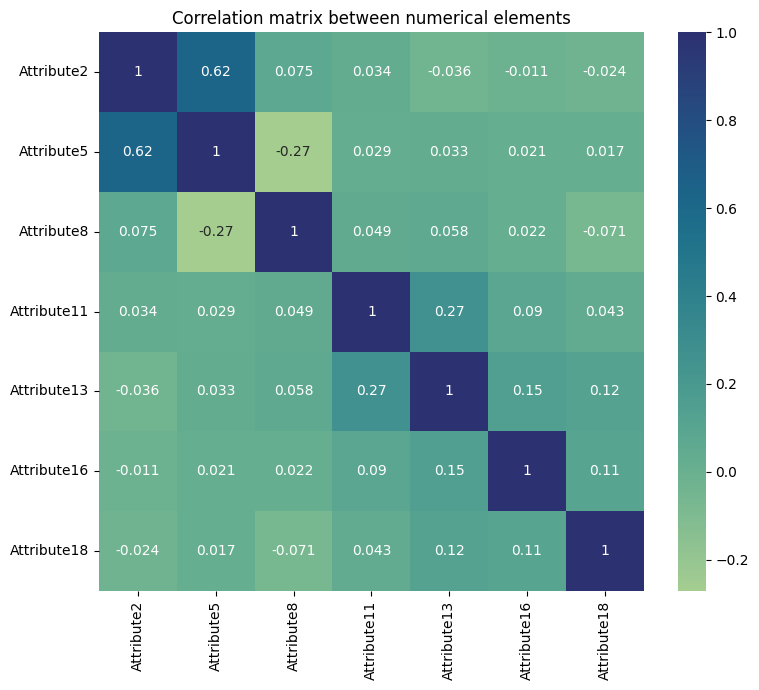

In [6]:
# 2.2 Correlation 
numeric = df.select_dtypes(include='int64').columns # numeric columns list
cor_matrix = df[numeric].corr() # correlation matrix

plt.figure(figsize=(8, 7)) # plotting
sns.heatmap(data=cor_matrix, annot=True, cmap='crest')
plt.title('Correlation matrix between numerical elements')

plt.tight_layout()
plt.show()


In [148]:
# top 3 numerical attributes correlated with target 
y_copy = y == 2 # if y = 2, then it is True, if y = 1 then row has value False
gen = pd.concat([df[numeric], y_copy], axis=1)
cor_feat_targ = gen[numeric].corrwith(gen['class']).sort_values(ascending=False)

print('Top 3 most correlated numerical attributes with target')
print(cor_feat_targ.iloc[:3])

Top 3 most correlated numerical attributes with target
Attribute2    0.214927
Attribute5    0.154739
Attribute8    0.072404
dtype: float64


Note that I marked 2 as True, as if my target was called 'class_bad'

Thus,

Attribute 2, 5 and 8 is most correlated with target variable.
Attribute 2 is duration in month and attribute 5 is credit amount
and Attribute 8 is installment rage in percents of disposable income.

### 3) Preprocessing
#### Task 3.1 Split train/test
● Split into train/test (e.g., 80/20)
● Use random_state for reproducibility
#### Task 3.2 Prepare pipeline
● Categorical → OneHotEncode

● Numeric → StandardScaler (if required)

In [167]:
# task 3.1 split train/test


X_train, X_test, y_train, y_test = train_test_split(df, column_or_1d(y_copy, warn=False), test_size = 0.2, random_state = 42)

numeric = df.select_dtypes(include='int64').columns
categorical = df.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ]
)

pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
    ]
)

### 4) Build 3 Baseline Models (No Tuning)
Train exactly these 3 models:
1. Logistic Regression
2. Decision Tree
3. kNN

#### Task 4.1 Train models
- Fit each model using the same preprocessing pipeline.

#### Task 4.2 Evaluate models
For each model, compute:
- Accuracy
- Confusion Matrix
- Precision, Recall, F1


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

For model LogisticRegression
Accuracy: 0.795
F1-score: 0.616822429906542
Precision: 0.6875
Recall: 0.559322033898305 

For model K-Neighbors
Accuracy: 0.765
F1-score: 0.5052631578947369
Precision: 0.6666666666666666
Recall: 0.4067796610169492 

For model Decision Tree
Accuracy: 0.7
F1-score: 0.5
Precision: 0.4918032786885246
Recall: 0.5084745762711864 



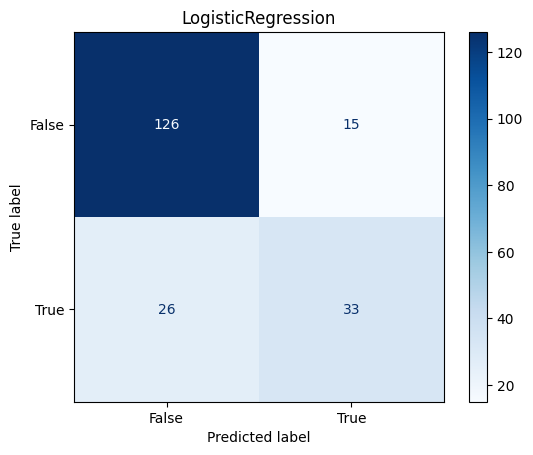

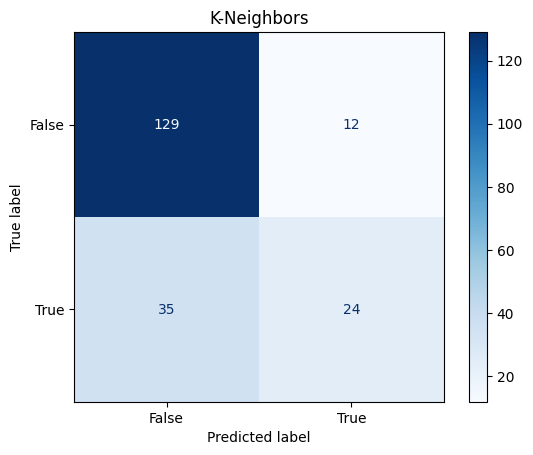

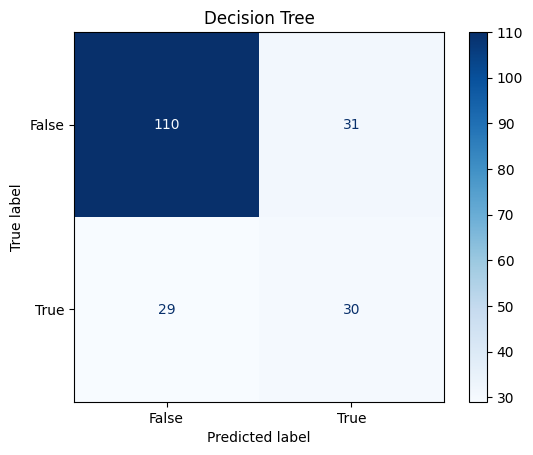

In [164]:
# modifying pipeline 
numeric = df.select_dtypes(include='int64').columns
categorical = df.select_dtypes(include='object').columns

# making dictionaries consisting of models and respected pipelines
models = {
    'LogisticRegression' : LogisticRegression(),
    'K-Neighbors' : KNeighborsClassifier(),
    'Decision Tree' : DecisionTreeClassifier()
}
pipes = {}

# training
for model in models:
    pipes[model] = Pipeline(
        steps = [
            ('preprocessor', preprocessor),
            ('classifier', models[model])
        ]
    )
    pipes[model].fit(X_train, y_train)

# cross-validation (confusion matrix, precision, recall, f1)
for model in models:
    y_pred = pipes[model].predict(X_test)

    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap=plt.cm.Blues,
    )
    disp.ax_.set_title(model)
    print('For model', model)
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('F1-score:', f1_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred), '\n')

plt.show()


In this case, we need to maximize Recall, because of cost matrix.

In credit risk, of course it is very important to not mark anyone good when they are bad, we need a very recalling model.


### 5) Simple “Business Threshold”
Logistic regression outputs probabilities

Compare 3 thresholds

Compute confusion matrix and metrics (f1, recall, precision) for for test set:
● Threshold = 0.65
● Threshold = 0.50
● Threshold = 0.35

For threshold 65 percent
Accuracy: 0.79
Precision: 0.7741935483870968
Recall: 0.4067796610169492
F1-score: 0.5333333333333334 

For threshold 50 percent
Accuracy: 0.795
Precision: 0.6875
Recall: 0.559322033898305
F1-score: 0.6168224299065421 

For threshold 35 percent
Accuracy: 0.765
Precision: 0.5789473684210527
Recall: 0.7457627118644068
F1-score: 0.6518518518518519 



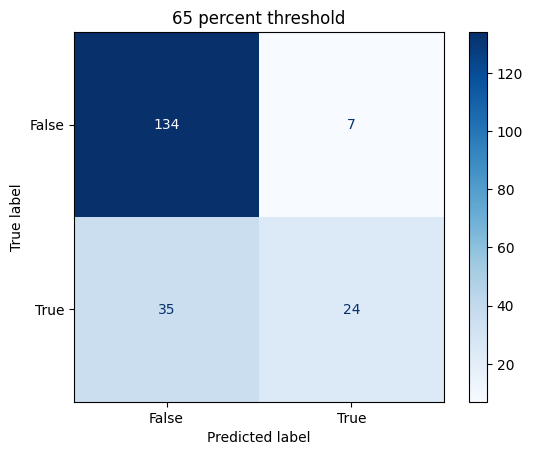

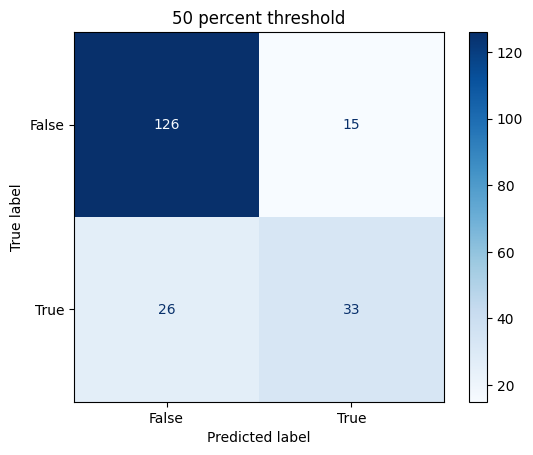

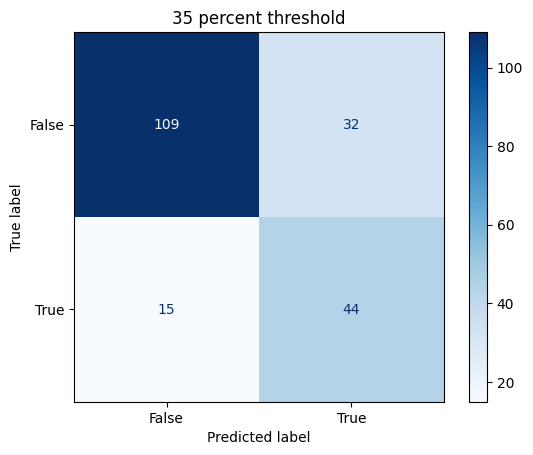

In [198]:
lr = pipes['LogisticRegression']

thresholds = {
    '65 percent' : (lr.predict_proba(X_test)[:, 1] >= 0.65),
    '50 percent' : lr.predict(X_test),
    '35 percent': (lr.predict_proba(X_test)[:, 1] >= 0.35)
}

for threshold in thresholds:
    accuracy = accuracy_score(y_true=y_test, y_pred=thresholds[threshold])
    precision = precision_score(y_true=y_test, y_pred=thresholds[threshold])
    recall = recall_score(y_true=y_test, y_pred=thresholds[threshold])
    f1 = 2*(precision*recall)/(precision+recall)
    print('For threshold', threshold)
    print('Accuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1-score:', f1, '\n')

    disp = ConfusionMatrixDisplay.from_predictions(
            y_test,
            thresholds[threshold],
            cmap=plt.cm.Blues,
        )
    title = threshold + ' threshold' # something like "35 percent threshold"
    disp.ax_.set_title(title)


The threshold with best recall and also f1-score is 35 percent, though, precision isn't very good. Even if this error has less cost, it's still an error.


### 6) Production-Oriented task: “Manual Review Queue”
In real banks, not all decisions are automatic.
Task 6.1 Create 3 decision zones using probability

Using logistic regression probability p:
● Auto-approve: p < 0.20
● Manual review: 0.20 ≤ p ≤ 0.50
● Auto-reject: p > 0.50

Deliverables:
● Count how many applications fall in each zone
● Business interpretation: how this reduces workload and risk

In [203]:
lr = pipes['LogisticRegression'] 

thresholds = {
    'Auto-Reject' : np.where(lr.predict_proba(X_test)[:, 1] > 0.5), # if p > 0.5
    'Manual Review' : np.where((lr.predict_proba(X_test)[:, 1] >= 0.2) & (lr.predict_proba(X_test)[:, 1] <= 0.5)), # if 0.2 < p < 0.5 
    'Auto-Approve': np.where(lr.predict_proba(X_test)[:, 1] < 0.2) # if p < 0.2
}

for threshold in thresholds:
    print(threshold)
    print(len(thresholds[threshold][0]))

del lr, thresholds

Auto-Reject
48
Manual Review
67
Auto-Approve
85


If it is model even more accurate than logistic regression (like SVM), Auto-Approval and Auto-Reject makes job less routineful for dipsatchers who checks applications. 
They less, but probably more ambiguous data to check. I think we can check auto-reject and auto-approve some of applications, and then use left data for some other models. And after it give the most ambigous to group of operators.

### 7) Business Demonstration
Create a final markdown section:

Business Demo: Loan Approval Risk Model

Include:
1. Executive summary
- what dataset about
- what goal
- best model chosen
- key metric result
- recommended threshold
- how manual review queue works

2. One table comparing models
Rows: models

Columns: Accuracy, Recall (bad class), F1, comment (1 short sentence)

3. One visual
- Confusion matrix plot (matplotlib)

4. Example: 3 applicants
Take 3 rows from test set and show:
- probability
- predicted decision zone (approve/review/reject)
- 1–2 sentence explanation for each (business style)

1. Executive summary

Dataset is about german credits taken, where rows are subjects (individual notes) and columns are subjects features.

Goal is detecting what is fraud and what isn't.

Best model chosen - Logistic Regression with 35 percent threshold, for recall and F1-score. 

Key metric result - Recall (or Specifity), because we should NOT miss any real fraud.

Recommended threshold - 0.35 for logistic regression (I experimentally came up with 0.382), but we should use ROC-AUC to find best one. 

2. One table comparing models



In [ ]:
# Note:
# I decided to use 0.35 threshold for furhter predicitons
# Table will be filled with accuracy, f1-score and recall for THIS threshold

table = pd.DataFrame(index=models.keys(),  columns=['Accuracy', 'Recall', 'F1_score', 'Comment'])
for model in models:
    y_pred_current = pipes[model].predict_proba(X_test)[:, 1] >= 0.35
    accuracy = accuracy_score(y_test, y_pred_current)
    recall = recall_score(y_test, y_pred_current)
    f1 = f1_score(y_test, y_pred_current)

    table.loc[model] = (
        {
        'Accuracy' : accuracy,
        'Recall' : recall,
        'F1_score' : f1,
        'Comment' : "Threshold 35%, data size: 200"
        }
    )

display(table)

,Accuracy,Recall,F1_score,Comment
LogisticRegression,0.765,0.745763,0.651852,"Threshold 35%, data size: 200"
K-Neighbors,0.725,0.728814,0.609929,"Threshold 35%, data size: 200"
Decision Tree,0.7,0.508475,0.5,"Threshold 35%, data size: 200"


3. One visual
- Confusion matrix plot (matplotlib)

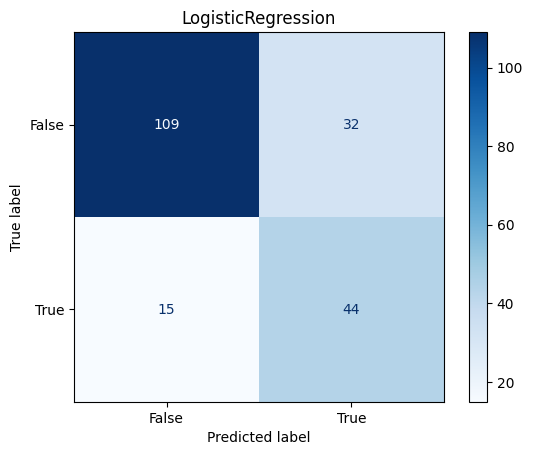

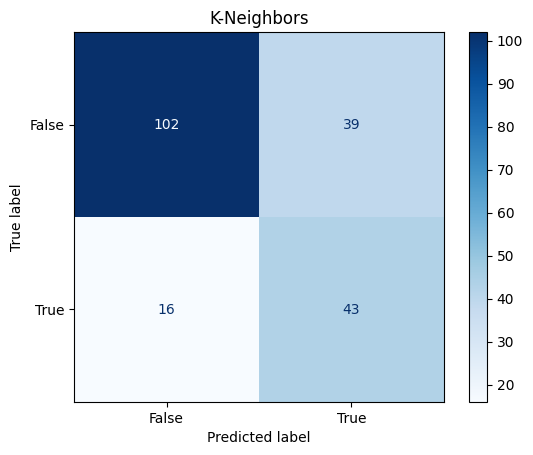

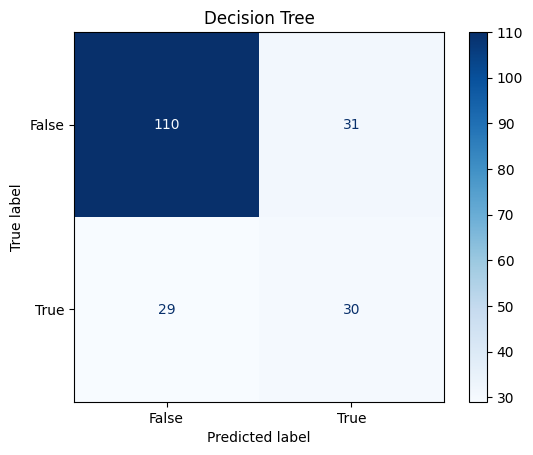

In [202]:
for model in models:
    y_pred_current = pipes[model].predict_proba(X_test)[:, 1] >= 0.35
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_current,
        cmap=plt.cm.Blues
    )
    disp.ax_.set_title(model)


Example: 3 applicants

Take 3 rows from test set and show:
- probability
- predicted decision zone (approve/review/reject)
- 1–2 sentence explanation for each (business style)

In [243]:
# 3 applicants (sample)
applicants = X_test.sample(3, random_state=42).reset_index(drop=True)
display(applicants)

# predictions
lr = pipes['LogisticRegression']
thresholds = {
    'Auto-Reject' : np.where(lr.predict_proba(X_test)[:, 1] > 0.5), # if p > 0.5
    'Manual Review' : np.where((lr.predict_proba(X_test)[:, 1] >= 0.2) & (lr.predict_proba(X_test)[:, 1] <= 0.5)), # if 0.2 < p < 0.5 
    'Auto-Approve': np.where(lr.predict_proba(X_test)[:, 1] < 0.2) # if p < 0.2
}

# series with probabilities
proba = lr.predict_proba(applicants)[:, 1]
proba = pd.Series(data=proba)
print('Probabilities of fraud for each row:')
display(proba)

# table with predicted decision zones
choices = ['Auto-Approve', 'Manual Review', 'Auto-Reject']
conditions = [proba < 0.2, (proba >= 0.2) & (proba <= 0.5), proba > 0.5]

decision_zones = pd.DataFrame(
    {
        'Decision' : np.select(conditions, choices, default='Unknown'),
        'Probability' : proba
    }
)
display(decision_zones)

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A14,6,A32,A45,660,A63,A74,2,A94,A101,4,A121,23,A143,A151,1,A172,1,A191,A201
1,A11,18,A32,A42,4153,A61,A73,2,A93,A102,3,A123,42,A143,A152,1,A173,1,A191,A201
2,A12,13,A34,A43,882,A61,A72,4,A93,A103,4,A121,23,A143,A152,2,A173,1,A191,A201


Probabilities of fraud for each row:


0    0.089391
1    0.283915
2    0.101585
dtype: float64

,Decision,Probability
0,Auto-Approve,0.089391
1,Manual Review,0.283915
2,Auto-Approve,0.101585


Explanations:
I will use most correlated numerical and categorical attributes to explain it in business way.

First candidate has a 6 month credit and has previous credits paid back, credit amount is 660$, and in general looks like a very good risks according to model.

Second candidate has a 18 month credit, previous credits paid back and larger amount of credit of 4153$, needs to be manually checked.

Third candidate  has a 13 month credit, critical credits and 882$ of credit amount. Maybe we should manually check this row, but according to other rows, model can approve it, maybe its the case of false positive.

Summary:
In this practice I studied german data of credits taken, preprocessed and used some sort of feature selection,
after that I set up pipeline and preprocessor, and learn three models, cross-validated result and set up threshold for model.
Estimated each model by their metrics (F1, Accuracy, Recall), viewed confusion matrix, and then showed how Logistic Regression (best of the models) works on three randomly chosen rows.